# M12 — controls on the analytic tiers

M9–M10 measured order collapse, "stability absent," a matched-h crossover, and
concluded the reparameterisation "only pays off on the real network." A review
(`docs/MILESTONES_M11-M13.md`, 2026-09-24) found each of those rested on a
comparison made under *different settings* than the one it was compared to.
This notebook redoes each comparison under matched settings, on the laptop —
no GPU needed, since Tier 3's own numbers (`results/tier3_error.csv`) are
already committed from M9.

| # | What M9/M10 claimed | What was actually compared | Fix |
|---|---|---|---|
| 12.1 | order collapses on Tier 3 ("a factor of 33") | Tiers 1-2 swept t_end=0.2; Tier 3 swept t_end=1e-3, NFE 8-120 | re-sweep Tiers 1-2 at Tier 3's *exact* protocol |
| 12.2 | "stability claim refuted" | only tested on the *linear*, decoupled Tier 1 | run the project's own `max_stable_h` on the *nonlinear* Tier 2 |
| 12.3 | crossover at nfe3* = 4.4-5.0 (T1), = 8.9 (T2) | compared at matched **step count**, not matched **NFE** (order 3 spends 3x) | `crossover_nfe`, all three tiers |
| 12.4 | (new) | - | when does the split actually help vs hurt? |

Every number below is generated fresh in this notebook (no numbers are copied
from the review) -- they should be read as an independent reproduction, and
where they land close to the review's own figures that is itself a validation
of both.

In [1]:
import sys, pathlib, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

p = pathlib.Path.cwd()
while not (p / "pyproject.toml").exists() and p != p.parent:
    p = p.parent
ROOT = p
sys.path.insert(0, str(ROOT))

from src.grids import grid_t, grid_lambda
from src.solvers import integrate
from src.arm_c import sample_dpm_solver
from src.testbeds import GaussianTier1, MixtureTier2, swiss_roll, dop853_reference
from src.metrics import fit_order, l2
from src.stability import max_stable_h
from src.crossover import crossover_nfe
from src.runlog import append_row, load

RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"
T, T_END = 1.0, 1e-3
SEED = 0
np.set_printoptions(precision=4, suppress=True)


## 12.1 -- the matched protocol

Tier 1 (kappa=10, d=3, M5's own setting) and Tier 2 (`mog8`, M7's own setting),
swept at Tier 3's *exact* NFE budgets and `t_end`. Extended down to NFE=3
(below M9's floor of 10) so section 12.3's crossover search has room to find a
crossing that may sit below the "practitioner" range.

In [2]:
NFE_BUDGETS = [3, 4, 5, 6, 8, 10, 12, 15, 20, 30, 50, 80, 120]
ARM_AB = {"euler": 1, "midpoint": 2, "rk4": 4}   # solver -> NFE per step
ARM_C = {"dpm1": 1, "dpm2": 2, "dpm3": 3}        # solver -> order

def sweep(tb, xT, ref, testbed_name, kappa):
    rows = []
    for arm, rhs, gridf in [
        ("A", tb.rhs_t, lambda n: grid_t(T, T_END, n)),
        ("B", tb.rhs_lambda, lambda n: grid_lambda(T, T_END, n)),
    ]:
        for solver, per in ARM_AB.items():
            for b in NFE_BUDGETS:
                n = max(1, b // per)
                g = gridf(n)
                xf, nfe = integrate(rhs, xT, g, solver)
                div = bool(np.isnan(nfe))
                err = np.nan if div else l2(xf, ref)
                rows.append(dict(tier=None, testbed=testbed_name, arm=arm, solver=solver,
                                  order=per, kappa=kappa, h=abs(g[1] - g[0]), nfe=nfe,
                                  err_l2=err, diverged=div, seed=SEED))
    for solver, order in ARM_C.items():
        for b in NFE_BUDGETS:
            steps = max(order, (b // order) * order)
            xf, nfe = sample_dpm_solver(tb.eps, xT, T, T_END, order=order, steps=steps)
            rows.append(dict(tier=None, testbed=testbed_name, arm="C", solver=solver,
                              order=order, kappa=kappa, h=np.nan, nfe=nfe,
                              err_l2=l2(xf, ref), diverged=False, seed=SEED))
    return rows

tb1 = GaussianTier1(kappa=10.0, d=3, seed=SEED)
xT1 = tb1.x_T(5)
ref1 = tb1.exact(xT1, T, T_END)
rows1 = sweep(tb1, xT1, ref1, "gaussian", 10.0)
for r in rows1:
    r["tier"] = 1

mu = swiss_roll(n=8, noise=0.0, seed=0)
tb2 = MixtureTier2(mu, seed=SEED)
xT2 = tb2.x_T(5)
ref2 = dop853_reference(tb2, xT2, T, T_END)
rows2 = sweep(tb2, xT2, ref2, "mog8", np.nan)
for r in rows2:
    r["tier"] = 2

CSV = RESULTS / "controls_matched_protocol.csv"
CSV.unlink(missing_ok=True)
for r in rows1 + rows2:
    append_row(str(CSV), **r)

df12 = load(str(CSV))
print(len(df12), "rows ->", CSV.relative_to(ROOT))


234 rows -> results\controls_matched_protocol.csv


### The Finding-2 table, reproduced

Slope fit two ways per curve: `fit_order`'s auto sliding window, and a plain
fit over the *entire* practitioner range (NFE 10-120) -- the difference
between them is itself evidence of pre-asymptotic behaviour. The `t_end=0.2`
columns are M5/M7's original, unchanged sweeps (`results/tier1_order.csv`,
`tier2_order.csv`), read here as the "this is what asymptotic looks like"
baseline. Tier 3 is read from M9's already-committed `tier3_error.csv` --
no GPU needed for this comparison, it was already run.

In [3]:
def slopes_for(df, tier_filter):
    out = {}
    d = df[df["tier"] == tier_filter] if tier_filter is not None else df
    for (arm, solver), g in d.groupby(["arm", "solver"]):
        g = g.sort_values("nfe")
        g_prac = g[g["nfe"] >= 9]  # dpm3's real nfe for budget=10 floors to 9
        auto = fit_order(1.0 / g_prac["nfe"].to_numpy(), g_prac["err_l2"].to_numpy())
        full = np.polyfit(np.log(1.0 / g_prac["nfe"].to_numpy()),
                          np.log(g_prac["err_l2"].to_numpy()), 1)[0]
        out[(arm, solver)] = dict(theory=int(g["order"].iloc[0]),
                                  auto=auto["slope"], full=float(full))
    return out

def asymptotic_slopes(csv_name):
    out = {}
    p = RESULTS / csv_name
    if p.exists():
        d = load(str(p))
        for (arm, solver), g in d.groupby(["arm", "solver"]):
            g = g.sort_values("h", ascending=False)
            out[(arm, solver)] = fit_order(g["h"].to_numpy(), g["err_l2"].to_numpy())["slope"]
    return out

asym1 = asymptotic_slopes("tier1_order.csv")
asym2 = asymptotic_slopes("tier2_order.csv")

t3_path = RESULTS / "tier3_error.csv"
slope3 = {}
if t3_path.exists():
    d3 = load(str(t3_path))
    for (arm, solver), g in d3.groupby(["arm", "solver"]):
        g = g.sort_values("h", ascending=False)
        slope3[(arm, solver)] = fit_order(g["h"].to_numpy(), g["err_l2"].to_numpy())["slope"]

s1 = slopes_for(df12, 1)
s2 = slopes_for(df12, 2)

rows = []
for key in sorted(set(s1) | set(s2)):
    arm, solver = key
    theory = s1.get(key, s2.get(key, {})).get("theory")
    rows.append(dict(
        arm=arm, solver=solver, theory=theory,
        tier1_matched_auto=s1.get(key, {}).get("auto"),
        tier1_matched_full=s1.get(key, {}).get("full"),
        tier1_asymptotic_t02=asym1.get(key),
        tier2_matched_auto=s2.get(key, {}).get("auto"),
        tier2_matched_full=s2.get(key, {}).get("full"),
        tier2_asymptotic_t02=asym2.get(key),
        tier3_network=slope3.get(key),
    ))
finding2 = pd.DataFrame(rows).sort_values(["arm", "solver"]).reset_index(drop=True)
pd.set_option("display.width", 180)
finding2.round(3)


,arm,solver,theory,tier1_matched_auto,tier1_matched_full,tier1_asymptotic_t02,tier2_matched_auto,tier2_matched_full,tier2_asymptotic_t02,tier3_network
0,A,euler,1,0.871,0.871,1.012,1.269,1.269,1.012,0.842
1,A,midpoint,2,2.403,2.403,2.028,1.485,1.485,2.031,1.525
2,A,rk4,4,3.297,3.297,3.938,2.093,2.093,3.997,1.210
3,B,euler,1,1.073,1.073,1.023,1.191,1.191,1.023,0.746
4,B,midpoint,2,1.786,1.838,2.057,2.385,2.863,2.055,1.603
5,B,rk4,4,4.829,4.829,3.921,4.523,4.523,3.965,2.231
6,C,dpm1,1,0.958,0.958,0.994,1.325,2.168,0.996,0.813
7,C,dpm2,2,2.100,2.100,2.028,2.455,2.941,2.018,2.191
8,C,dpm3,3,3.492,3.492,3.094,4.214,4.214,3.084,2.473


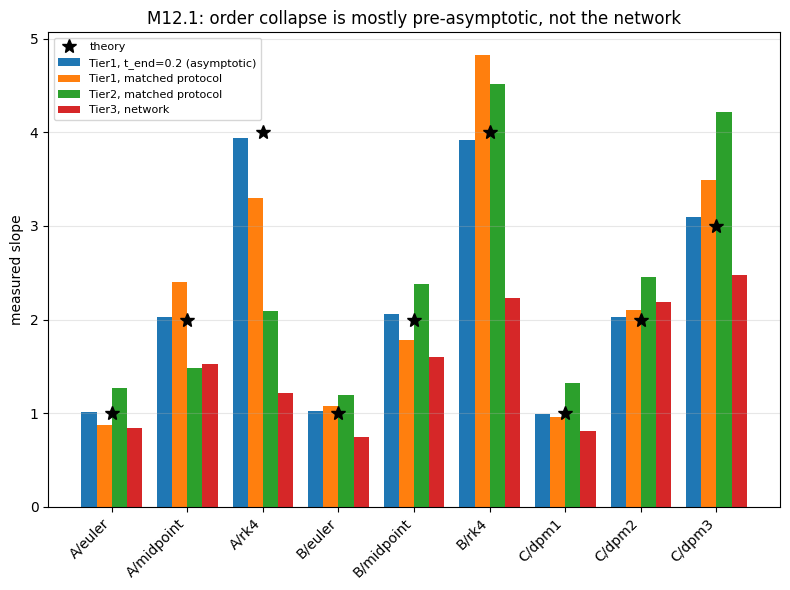

worst |slope-theory|, Tier2 matched protocol : 1.907
worst |slope-theory|, Tier2 asymptotic (t=0.2): 0.084
Most of the gap from theory is already present with an EXACT score (no
network at all) once the settings are matched to Tier 3's own budgets.


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
xs = np.arange(len(finding2))
w = 0.2
ax.bar(xs - 1.5*w, finding2["tier1_asymptotic_t02"], w, label="Tier1, t_end=0.2 (asymptotic)")
ax.bar(xs - 0.5*w, finding2["tier1_matched_auto"], w, label="Tier1, matched protocol")
ax.bar(xs + 0.5*w, finding2["tier2_matched_auto"], w, label="Tier2, matched protocol")
ax.bar(xs + 1.5*w, finding2["tier3_network"], w, label="Tier3, network")
ax.plot(xs, finding2["theory"], "k*", ms=10, label="theory", zorder=5)
ax.set_xticks(xs)
ax.set_xticklabels([f"{a}/{s}" for a, s in zip(finding2["arm"], finding2["solver"])],
                    rotation=45, ha="right")
ax.set_ylabel("measured slope")
ax.set_title("M12.1: order collapse is mostly pre-asymptotic, not the network")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / "12_matched_protocol.png", dpi=150)
plt.show()

gap_matched = (finding2["tier2_matched_auto"] - finding2["theory"]).abs()
gap_asym = (finding2["tier2_asymptotic_t02"] - finding2["theory"]).abs()
print("worst |slope-theory|, Tier2 matched protocol :", round(gap_matched.max(), 3))
print("worst |slope-theory|, Tier2 asymptotic (t=0.2):", round(gap_asym.max(), 3))
print("Most of the gap from theory is already present with an EXACT score (no")
print("network at all) once the settings are matched to Tier 3's own budgets.")


## 12.2 -- stability on the nonlinear tier

M6 found arm A never destabilizes on Tier 1 and attributed the flatness to a
cancellation specific to the *linear*, decoupled problem. `max_stable_h` is
this project's own bisection -- run here, unmodified, on `mog8` instead.

In [5]:
# A fresh MixtureTier2(mu, seed=0) per call: x_T draws from a stateful rng,
# so reusing one tb across this loop would silently hand each stepper a
# DIFFERENT noise draw. A fresh tb per call means every stepper is tested
# against the identical, reproducible first draw from seed 0.
STEPPERS5 = ["euler", "midpoint", "heun3", "rk4", "ab2"]
STEPPER_ORDER = {"euler": 1, "midpoint": 2, "heun3": 3, "rk4": 4, "ab2": 2}

CSV2 = RESULTS / "stability_tier2.csv"
CSV2.unlink(missing_ok=True)
for arm in ("A", "B"):
    for name in STEPPERS5:
        tb_i = MixtureTier2(mu, seed=SEED)
        h = max_stable_h(tb_i, arm, name, T=T, t_end=T_END)
        append_row(str(CSV2), tier=2, testbed="mog8", arm=arm, solver=name,
                   order=STEPPER_ORDER[name], kappa=np.nan, h=h, nfe=np.nan,
                   err_l2=np.nan, diverged=bool(np.isnan(h)), seed=SEED)

stab2 = load(str(CSV2))
piv = stab2.pivot_table(index="solver", columns="arm", values="h")
print(piv)


arm            A         B
solver                    
ab2       0.4995  4.791347
euler     0.4995  4.791347
heun3     0.4995  4.791347
midpoint  0.4995  4.791347
rk4       0.1998  4.791347


In [6]:
# The mechanism: a numerical Jacobian of rhs_t, near the stiff boundary,
# Tier 1 (linear, decoupled) vs Tier 2 (nonlinear mixture).
def jacobian_norm(tb, t, x, eps=1e-5):
    x = np.atleast_2d(x).astype(np.float64)
    d = x.shape[1]
    f0 = tb.rhs_t(x, t).ravel()
    J = np.zeros((d, d))
    for j in range(d):
        dx = np.zeros_like(x)
        dx[0, j] = eps
        f1 = tb.rhs_t(x + dx, t).ravel()
        J[:, j] = (f1 - f0) / eps
    return np.linalg.norm(J, 2)  # spectral norm

ts = np.array([0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 5e-3, 1e-3])
tb1_j = GaussianTier1(kappa=10.0, d=3, seed=0)
x1 = tb1_j.x_T(1)
tb2_j = MixtureTier2(mu, seed=0)
x2 = tb2_j.x_T(1)

jac_rows = []
for t in ts:
    jac_rows.append(dict(t=t, tier=1, jacobian_norm=jacobian_norm(tb1_j, t, x1)))
    jac_rows.append(dict(t=t, tier=2, jacobian_norm=jacobian_norm(tb2_j, t, x2)))
jac = pd.DataFrame(jac_rows)
print(jac.pivot(index="t", columns="tier", values="jacobian_norm"))


tier          1           2
t                          
0.001  0.538957  545.217865
0.005  0.891076  133.172168
0.010  1.319157   74.862618
0.020  2.114193   41.514420
0.050  3.780911   16.820885
0.100  4.359817    5.516449
0.200  2.966454    3.154352
0.500  0.384959    0.397883


     solver  h_default_factor10_xT  h_strict_factor2_datamode
0     euler                 0.4995                     0.4995
1  midpoint                 0.4995                     0.4995
2     heun3                 0.4995                     0.4995
3       rk4                 0.1998                     0.1998
4       ab2                 0.4995                     0.4995


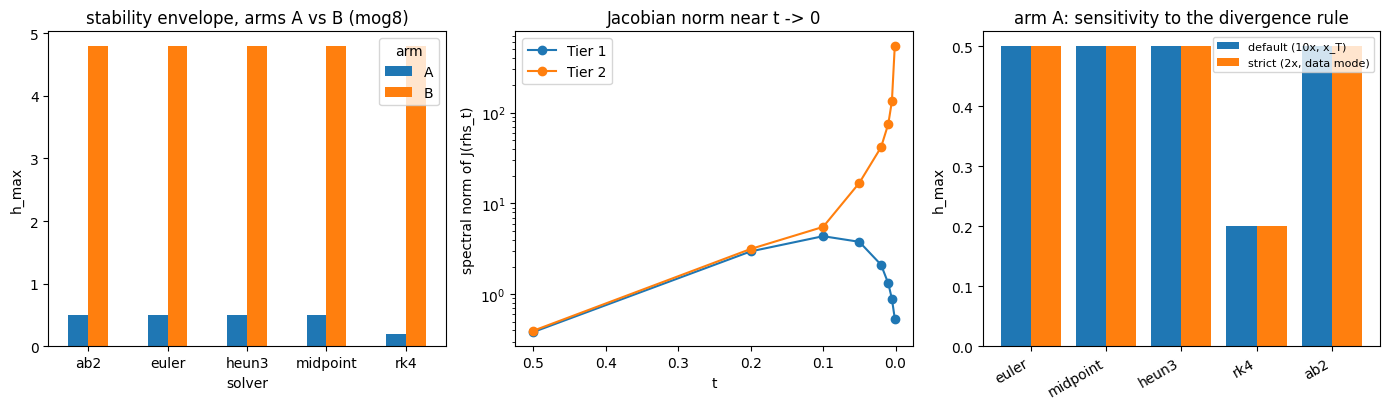

A/rk4 h_max = 0.1998  (review's own check: 0.1998)


In [7]:
# Sensitivity of "stable" to the divergence rule: default (factor=10, ref=x_T)
# vs a stricter rule (factor=2, against the largest data-mode norm instead of
# the noise norm -- diverging past 2x the *data* scale, not 10x the *noise* scale).
largest_mode = mu[np.argmax(np.linalg.norm(mu, axis=1))][None, :]

sens_rows = []
for name in STEPPERS5:
    tb_d = MixtureTier2(mu, seed=SEED)
    h_default = max_stable_h(tb_d, "A", name, T=T, t_end=T_END)
    tb_s = MixtureTier2(mu, seed=SEED)
    h_strict = max_stable_h(tb_s, "A", name, T=T, t_end=T_END, factor=2.0, ref=largest_mode)
    sens_rows.append(dict(solver=name, h_default_factor10_xT=h_default,
                          h_strict_factor2_datamode=h_strict))
sens = pd.DataFrame(sens_rows)
print(sens)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

piv.plot(kind="bar", ax=axes[0])
axes[0].set_ylabel("h_max"); axes[0].set_title("stability envelope, arms A vs B (mog8)")
axes[0].tick_params(axis="x", rotation=0)

for tier, g in jac.groupby("tier"):
    axes[1].semilogy(g["t"], g["jacobian_norm"], "o-", label="Tier " + str(tier))
axes[1].invert_xaxis()
axes[1].set_xlabel("t"); axes[1].set_ylabel("spectral norm of J(rhs_t)"); axes[1].legend()
axes[1].set_title("Jacobian norm near t -> 0")

xs = np.arange(len(sens))
axes[2].bar(xs - 0.2, sens["h_default_factor10_xT"], 0.4, label="default (10x, x_T)")
axes[2].bar(xs + 0.2, sens["h_strict_factor2_datamode"], 0.4, label="strict (2x, data mode)")
axes[2].set_xticks(xs); axes[2].set_xticklabels(sens["solver"], rotation=30, ha="right")
axes[2].set_ylabel("h_max"); axes[2].legend(fontsize=8)
axes[2].set_title("arm A: sensitivity to the divergence rule")

fig.tight_layout()
fig.savefig(FIGURES / "12_stability_tier2.png", dpi=150)
plt.show()

print("A/rk4 h_max =", round(piv.loc["rk4", "A"], 4), " (review's own check: 0.1998)")


## 12.3 -- crossover at matched NFE, all three tiers

M8's `crossover_h` compared DPM-1 and DPM-3 at matched **step size** -- but
DPM-3 spends 3x the NFE per step, so that is not the paper's comparison.
`crossover_nfe` (new in `src/crossover.py`, same axis-agnostic core) finds
where the two curves cross on the **measured NFE** axis instead. Tier 3 needs
no new run -- `dpm1`/`dpm3` are already in `results/tier3_error.csv` from M9,
just never compared this way.

In [8]:
def dpm_curve(df, tier, solver):
    g = df[(df["tier"] == tier) & (df["arm"] == "C") & (df["solver"] == solver)].sort_values("nfe")
    return g["nfe"].to_numpy(), g["err_l2"].to_numpy()

CSV3 = RESULTS / "crossover_matched_nfe.csv"
CSV3.unlink(missing_ok=True)
cross_rows = []

for tier, testbed in [(1, "gaussian"), (2, "mog8")]:
    n1, e1 = dpm_curve(df12, tier, "dpm1")
    n3, e3 = dpm_curve(df12, tier, "dpm3")
    for c in crossover_nfe(n1, e1, n3, e3):
        cross_rows.append(dict(tier=tier, testbed=testbed, nfe_star=float(c)))

d3 = load(str(t3_path))
g1_3 = d3[(d3["arm"] == "C") & (d3["solver"] == "dpm1")].sort_values("nfe")
g3_3 = d3[(d3["arm"] == "C") & (d3["solver"] == "dpm3")].sort_values("nfe")
for c in crossover_nfe(g1_3["nfe"].to_numpy(), g1_3["err_l2"].to_numpy(),
                       g3_3["nfe"].to_numpy(), g3_3["err_l2"].to_numpy()):
    cross_rows.append(dict(tier=3, testbed="cifar10", nfe_star=float(c)))

cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv(CSV3, index=False)
print(cross_df)
print()
print("paper's Table 6 anomaly: order-3 far worse than order-1 at ~10 NFE.")
print("the rightmost (largest) crossing per tier is the practical one -- below")
print("it, order 1 can still be ahead due to re-crossing on the nonlinear tiers.")


   tier   testbed   nfe_star
0     1  gaussian   5.052066
1     2      mog8   9.188101
2     2      mog8  14.218662
3     2      mog8  17.325740
4     3   cifar10  14.076777

paper's Table 6 anomaly: order-3 far worse than order-1 at ~10 NFE.
the rightmost (largest) crossing per tier is the practical one -- below
it, order 1 can still be ahead due to re-crossing on the nonlinear tiers.


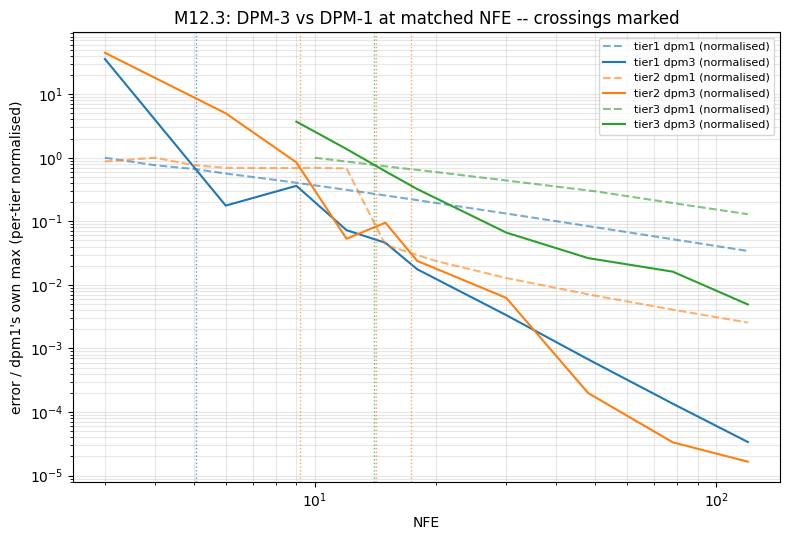

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for tier, testbed, color in [(1, "gaussian", "tab:blue"), (2, "mog8", "tab:orange"), (3, "cifar10", "tab:green")]:
    if tier == 3:
        n1, e1 = g1_3["nfe"].to_numpy(), g1_3["err_l2"].to_numpy()
        n3, e3 = g3_3["nfe"].to_numpy(), g3_3["err_l2"].to_numpy()
    else:
        n1, e1 = dpm_curve(df12, tier, "dpm1")
        n3, e3 = dpm_curve(df12, tier, "dpm3")
    ax.loglog(n1, e1 / e1.max(), "--", color=color, alpha=0.6, label="tier" + str(tier) + " dpm1 (normalised)")
    ax.loglog(n3, e3 / e1.max(), "-", color=color, label="tier" + str(tier) + " dpm3 (normalised)")
    for c in cross_df[cross_df["tier"] == tier]["nfe_star"]:
        ax.axvline(c, color=color, ls=":", lw=1, alpha=0.7)

ax.set_xlabel("NFE"); ax.set_ylabel("error / dpm1's own max (per-tier normalised)")
ax.set_title("M12.3: DPM-3 vs DPM-1 at matched NFE -- crossings marked")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / "12_crossover_matched_nfe.png", dpi=150)
plt.show()


## 12.4 -- when does the split help?

Sweep the data variance `s` (Tier 1 with `kappa = 1/s`, coordinate 0 only --
the problem is diagonal, so coordinate 1 at `s=1` cannot leak into coordinate
0's error) and compare DPM-1 vs Euler-in-t/lambda, DPM-2 vs RK2-in-t/lambda,
at practitioner NFE budgets. `tests/test_split_benefit.py` pins the `s=1`
point down exactly: the arm-A right-hand side is identically zero there
(Euler is then exact by construction), which DPM-Solver's exact-linear-part
split cannot know about or exploit.

In [10]:
def coord0_err(tb, xT, ref, method, nfe):
    if method == "dpm1":
        xf, _ = sample_dpm_solver(tb.eps, xT, T, T_END, order=1, steps=nfe)
    elif method == "dpm2":
        steps = max(2, (nfe // 2) * 2)
        xf, _ = sample_dpm_solver(tb.eps, xT, T, T_END, order=2, steps=steps)
    elif method == "euler_t":
        xf, _ = integrate(tb.rhs_t, xT, grid_t(T, T_END, nfe), "euler")
    elif method == "euler_lam":
        xf, _ = integrate(tb.rhs_lambda, xT, grid_lambda(T, T_END, nfe), "euler")
    elif method == "rk2_t":
        xf, _ = integrate(tb.rhs_t, xT, grid_t(T, T_END, max(1, nfe // 2)), "midpoint")
    elif method == "rk2_lam":
        xf, _ = integrate(tb.rhs_lambda, xT, grid_lambda(T, T_END, max(1, nfe // 2)), "midpoint")
    return float(abs(xf[0, 0] - ref[0, 0]))

METHODS = ["dpm1", "euler_t", "euler_lam", "dpm2", "rk2_t", "rk2_lam"]
s_values = np.logspace(-4, 0, 13)

CSV4 = RESULTS / "split_benefit.csv"
split_rows = []
for s in s_values:
    tb_s = GaussianTier1(kappa=1.0 / s, d=2, seed=SEED)
    xT_s = tb_s.x_T(3)
    ref_s = tb_s.exact(xT_s, T, T_END)
    for nfe in [10, 20, 50]:
        for method in METHODS:
            split_rows.append(dict(s=s, nfe=nfe, method=method,
                                   err=coord0_err(tb_s, xT_s, ref_s, method, nfe)))
split_df = pd.DataFrame(split_rows)
split_df.to_csv(CSV4, index=False)

piv20 = split_df[split_df.nfe == 20].pivot_table(index="s", columns="method", values="err")
piv20.round(6)


method,dpm1,dpm2,euler_lam,euler_t,rk2_lam,rk2_t
s,,,,,,
0.000100,0.000101,0.000056,0.001174,0.001139,0.001742,0.000925
0.000215,0.000173,0.000102,0.001412,0.000781,0.001861,0.001258
0.000464,0.000279,0.000166,0.001773,0.000224,0.002017,0.001761
0.001000,0.000429,0.000255,0.002270,0.000553,0.002181,0.002425
0.002154,0.000645,0.000383,0.002894,0.001515,0.002297,0.003160
0.004642,0.000957,0.000566,0.003602,0.002519,0.002294,0.003735
0.010000,0.001413,0.000837,0.004297,0.003292,0.002103,0.003811
0.021544,0.002079,0.001229,0.004802,0.003546,0.001679,0.003193
0.046416,0.003055,0.001804,0.004871,0.003203,0.001053,0.002203


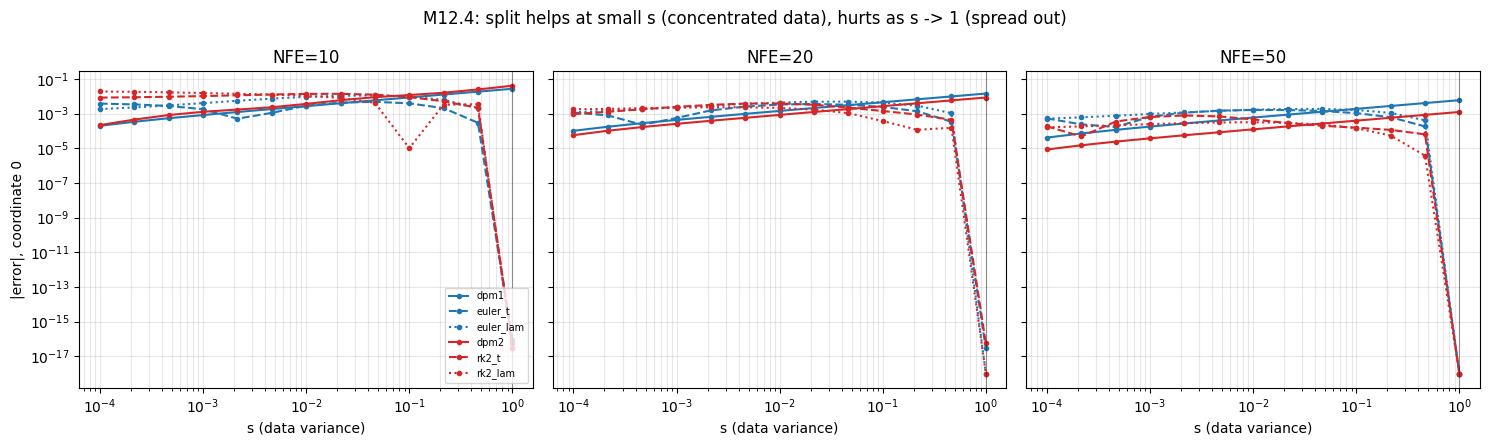

at small s (concentrated data): DPM beats plain Euler/RK2 more often than not:
  dpm1 < euler_t  : 83 % of points
  dpm2 < rk2_t    : 100 % of points


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, nfe in zip(axes, [10, 20, 50]):
    g = split_df[split_df.nfe == nfe]
    for method, color, ls in [("dpm1", "tab:blue", "-"), ("euler_t", "tab:blue", "--"),
                               ("euler_lam", "tab:blue", ":"), ("dpm2", "tab:red", "-"),
                               ("rk2_t", "tab:red", "--"), ("rk2_lam", "tab:red", ":")]:
        gm = g[g.method == method].sort_values("s")
        ax.loglog(gm["s"], gm["err"] + 1e-18, ls, color=color, marker="o", ms=3, label=method)
    ax.axvline(1.0, color="k", lw=0.8, alpha=0.4)
    ax.set_xlabel("s (data variance)"); ax.set_title("NFE=" + str(nfe))
    ax.grid(True, which="both", alpha=0.3)
axes[0].set_ylabel("|error|, coordinate 0")
axes[0].legend(fontsize=7, loc="lower right")
fig.suptitle("M12.4: split helps at small s (concentrated data), hurts as s -> 1 (spread out)")
fig.tight_layout()
fig.savefig(FIGURES / "12_split_benefit.png", dpi=150)
plt.show()

g20 = split_df[split_df.nfe == 20]
small_s = g20[g20.s < 1e-2]
dpm1_wins = (small_s[small_s.method=="dpm1"]["err"].values < small_s[small_s.method=="euler_t"]["err"].values).mean()
dpm2_wins = (small_s[small_s.method=="dpm2"]["err"].values < small_s[small_s.method=="rk2_t"]["err"].values).mean()
print("at small s (concentrated data): DPM beats plain Euler/RK2 more often than not:")
print("  dpm1 < euler_t  :", round(100 * dpm1_wins), "% of points")
print("  dpm2 < rk2_t    :", round(100 * dpm2_wins), "% of points")


**Why.** Near `s -> 0` almost all of the marginal variance `v(t) = alpha^2 s +
sigma^2` at moderate `t` comes from `sigma(t)^2` alone (the noise term), and
the posterior mean `x0_hat` is nearly constant (concentrated data) -- so the
*linear* part DPM-Solver integrates exactly dominates the right-hand side, and
solving it exactly is a real win. Near `s = 1` the two terms of `v(t)` are
comparable everywhere and the cancellation in `f(t) + g^2(t)/(2v(t))` that
makes arm A's right-hand side small is specific to `s = 1`, not to the linear
part in general -- DPM-Solver's split cannot see it, because it treats
*every* linear part as worth solving exactly regardless of how small the
nonlinear remainder already is.

## Validation -- run the unit tests

In [12]:
out = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_crossover.py", "tests/test_stability.py",
     "tests/test_split_benefit.py", "-q"],
    cwd=ROOT, capture_output=True, text=True,
)
print(out.stdout); print(out.stderr)
assert out.returncode == 0, "M12 tests failed"

for f in ["results/controls_matched_protocol.csv", "results/stability_tier2.csv",
          "results/crossover_matched_nfe.csv", "results/split_benefit.csv",
          "figures/12_matched_protocol.png", "figures/12_stability_tier2.png",
          "figures/12_crossover_matched_nfe.png", "figures/12_split_benefit.png"]:
    assert (ROOT / f).exists(), "missing deliverable: " + f
    print("  ok ", f)

print()
print("M12 validation: PASS")


.................                                                        [100%]


  ok  results/controls_matched_protocol.csv
  ok  results/stability_tier2.csv
  ok  results/crossover_matched_nfe.csv
  ok  results/split_benefit.csv
  ok  figures/12_matched_protocol.png
  ok  figures/12_stability_tier2.png
  ok  figures/12_crossover_matched_nfe.png
  ok  figures/12_split_benefit.png

M12 validation: PASS
